# Methods for minimizing a bidimensional function

In [1]:
using Pkg
ENV["PYTHON"] = ""
Pkg.build("PyCall")

    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/8f06b0cfa4c514c7b9546756dbae91fcfbc92dc9/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/9816a3826b0ebf49ab4926e2b18842ad8b5c8f04/build.log`


In [2]:
function golden_section(f, a, b, eps, alpha, max_iters = 1000000)
  lambda = a + (1 - alpha) * (b - a)
  mu = a + alpha * (b - a)
  f_lambda = f(lambda)
  f_mu = f(mu)

  while abs(b - a) > eps && max_iters > 0
    if f_lambda >= f_mu
      a = lambda
      lambda = mu
      f_lambda = f_mu
      mu = a + alpha * (b - a)
      f_mu = f(mu)
    else
      b = mu
      mu = lambda
      f_mu = f_lambda
      lambda = a + (1 - alpha) * (b - a)
      f_lambda = f(lambda)
    end

    max_iters -= 1
  end

  res = (a + b) / 2.0
  return a, b, res, f(res)
end

golden_section (generic function with 2 methods)

In [18]:
using ForwardDiff
using LinearAlgebra

function fletcher_reeves(f, x0::AbstractVector, eps::Real, max_iter::Int = 1000, verbose::Bool = false)
  x_k = copy(x0)
  k = 1
  
  grad_k = ForwardDiff.gradient(f, x_k)
  d_k = -grad_k

  if norm(grad_k) < eps
    return (xmin = x_k, fmin = f(x_k), iterations = k)
  end
  
  phi_1(lam) = f(x_k + lam * d_k)
  _, _, lambda_k, _ = golden_section(phi_1, 0, 10, 1e-6, (sqrt(5) - 1) / 2)
  
  x_k_plus_1 = x_k + lambda_k * d_k
  
  x1 = copy(x_k)
  g1 = copy(grad_k)
  d1 = copy(d_k)
  lam1 = lambda_k
  
  k = k + 1 
  
  while k <= max_iter
    grad_k_plus_1 = ForwardDiff.gradient(f, x_k_plus_1)
    
    beta_k = dot(grad_k_plus_1, grad_k_plus_1) / dot(grad_k, grad_k)
    d_k_plus_1 = -grad_k_plus_1 + beta_k * d_k
    
    if k == 2 && verbose
      println("First iteration details:")
      println("x1      = ", x1)
      println("grad1   = ", g1)
      println("d1      = ", d1)
      println("lambda1 = ", lam1)
      println("x2      = ", x_k_plus_1)
      println("grad2   = ", grad_k_plus_1)
      println("beta2   = ", beta_k)
      println("d2      = ", d_k_plus_1)
      println("")
    end
    
    phi_k(lam) = f(x_k_plus_1 + lam * d_k_plus_1)
    _, _, lambda_k_new, _ = golden_section(phi_k, 0, 10, 1e-6, (sqrt(5) - 1) / 2)
    
    x_new = x_k_plus_1 + lambda_k_new * d_k_plus_1
    grad_test = ForwardDiff.gradient(f, x_new)

    if norm(grad_test) < eps
      return (xmin = x_new, fmin = f(x_new), iterations = k)
    end
    
    k += 1
    
    x_k = x_k_plus_1
    grad_k = grad_k_plus_1
    d_k = d_k_plus_1
    
    x_k_plus_1 = x_new
  end
  
  return (xmin = x_k_plus_1, fmin = f(x_k_plus_1), iterations = max_iter)
end

fletcher_reeves (generic function with 3 methods)

### Comparison and plotting of all methods

In [16]:
using Plots
using Printf
using BenchmarkTools

function calculate_min_2d(alg, alg_name, f, x0, eps = 1e-4)
  result = alg(f, x0, eps)

  @printf("\n%s method: ", alg_name)
  @btime $alg($f, $x0, $eps)
  @printf("Minimum found at: x ~= [%.4f, %.4f]\n", result.xmin[1], result.xmin[2])
  @printf("With f(x) min ~= %.5e in %d iterations\n", result.fmin, result.iterations)

  x1_vals = range(min(x0[1], result.xmin[1]) - 1, max(x0[1], result.xmin[1]) + 1, length=100)
  x2_vals = range(min(x0[2], result.xmin[2]) - 1, max(x0[2], result.xmin[2]) + 1, length=100)
  
  f_plot(x, y) = f([x, y])
  p = contour(x1_vals, x2_vals, f_plot, levels=30, color=:viridis, xlabel="x1", ylabel="x2")

  scatter!(p, [x0[1]], [x0[2]], color=:blue, label="Start x0", markersize=4)
  scatter!(p, [result.xmin[1]], [result.xmin[2]], color=:red, label="Min found", markershape=:star5, markersize=6)

  annotate!(p, result.xmin[1], result.xmin[2], text("  Min", :left, :bottom, 8))
  
  return p
end

calculate_min_2d (generic function with 2 methods)

### Results for different functions and intervals

First iteration details:
x1      = [1.0, 1.0]
grad1   = [0.0, 2.0]
d1      = [-0.0, -2.0]
lambda1 = 0.16666663733543713
x2      = [1.0, 0.6666667253291257]
grad2   = [1.333333098683497, 3.519747542313212e-7]
beta2   = 0.444444288011265
d2      = [-1.333333098683497, -0.8888889279972843]


----------------------------------------
EVALUATING: Fletcher-Reeves (eps = 1e-1)
----------------------------------------

Fletcher-Reeves (eps = 1e-1) method:   9.638 μs (472 allocations: 15.45 KiB)
Minimum found at: x ~= [-0.0000, -0.0000]
With f(x) min ~= 3.59697e-14 in 2 iterations


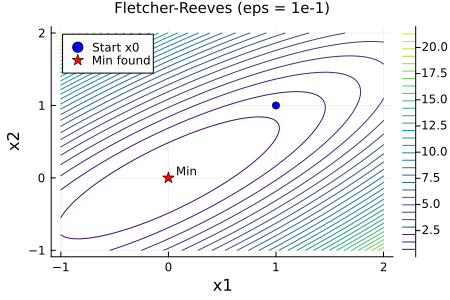

In [19]:
f_target(x) = 2*x[1]^2 - 4*x[1]*x[2] + 3*x[2]^2
x_init = [1.0, 1.0]
eps = 1e-1

fletcher_reeves(f_target, x_init, eps, 1000, true)

test_cases = [
  (name="Fletcher-Reeves (eps = 1e-1)", alg=fletcher_reeves, f=f_target, x0=x_init, eps=eps),
]

all_plots = []

for tc in test_cases
  println("\n" * "-"^40)
  println("EVALUATING: $(tc.name)")
  println("-"^40)
  
  p = calculate_min_2d(tc.alg, tc.name, tc.f, tc.x0, tc.eps)
  
  title!(p, tc.name, titlefontsize=10) 
  
  push!(all_plots, p)
end

n_cols = 1
n_rows = ceil(Int, length(test_cases) / n_cols)

plot(all_plots..., layout=(n_rows, n_cols), size=(450 * n_cols, 300 * n_rows))